# Historical and future LPJ-GUESS FPC aggregated to CLM groups

This FPC-only workflow follows the plotting structure of `explore_monthly_lpjguess_fpc`, while summing LPJ-GUESS PFTs into CLM target groups before analysis. 

NB: these are August peak-season fields rather than cellwise maxima; the max filenames are therefore a workflow label, not the mathematical operation used to produce each value.

## 1 · Configuration

In [2]:
from pathlib import Path
import re
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

REPO_DIR = Path.home() / "BOREAL-FOREST-EXPANSION"
DATA_DIR = REPO_DIR / "data/edit-surfdata/LPJ-GUESS"
FIGURE_DIR = Path("02-04-monthly-lpjguess-fpc-exploration-figures/CLM-PFTs")

FPC_FILES = {
    "Historical (1971–2000)": DATA_DIR / "mfpc_pft_avg_1971_2000_monthly_mean_fullgrid.out",
    "Future (2070–2100)": DATA_DIR / "mfpc_pft_avg_2070_2100_monthly_mean_fullgrid.out",
}
historical_name, future_name = FPC_FILES

FPC_ANNUAL_FUTURE = DATA_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt"
FPC_ANNUAL_HISTORICAL = DATA_DIR / "fpc1971to2000.txt"
REFERENCE_GRID = DATA_DIR / "gridlist45N_tundraboreal.txt"

LPJ_NATURAL = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]

# These are sums of LPJ-GUESS PFTs within each CLM target group.
# CLM (moss) remains intentionally unmapped and is not included in a group.
GROUPS = {
    "BoNET": ["BNE", "BINE"],
    "BoNDT (larch)": ["BNS"],
    "BoBDT": ["IBS"],
    "BoBDS shrubs": ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    "aC3": ["C3G", "GRT"],
    "temperate trees": ["TeNE", "TeBE", "TeBS"],
}

GROUP_COLORS = {
    "BoNET": "#145A32",
    "BoNDT (larch)": "#E67E22",
    "BoBDT": "#6B8E23",
    "BoBDS shrubs": "#D4A017",
    "aC3": "#8B5A2B",
    "temperate trees": "teal",
}

GROUPS_TO_MAP = list(GROUPS)
PRESENCE_THRESHOLD = 1e-6
PEAK_AMPLITUDE_TOLERANCE = 1e-8
SCALE_PERCENTILE = 99.5
MAP_EXTENT = [-180, 180, 45, 90]


def slug(text):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(text).strip().lower()).strip("_") or "figure"


def save_figure(fig, filename, directory=FIGURE_DIR, formats=("png", "pdf")):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    saved = []
    for extension in formats:
        path = directory / f"{slug(filename)}.{extension}"
        options = {"bbox_inches": "tight", "facecolor": "white"}
        if extension.lower() == "png":
            options["dpi"] = 300
        fig.savefig(path, **options)
        saved.append(path)
    return saved


for label, path in {
    **FPC_FILES,
    "Historical annual FPC template": FPC_ANNUAL_HISTORICAL,
    "Future annual FPC template": FPC_ANNUAL_FUTURE,
}.items():
    print(f"{label}: {path} ({'found' if path.exists() else 'MISSING'})")

Historical (1971–2000): /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_1971_2000_monthly_mean_fullgrid.out (found)
Future (2070–2100): /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_2070_2100_monthly_mean_fullgrid.out (found)
Historical annual FPC template: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/fpc1971to2000.txt (found)
Future annual FPC template: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100.txt (found)


## 2 · Load and validate monthly FPC

Repeated headers are removed before numeric conversion. Every represented grid cell must have exactly months 1–12 and no missing FPC values within its monthly rows. Geographic lon–lat combinations absent from the sparse domain remain masked after conversion to xarray.

In [3]:
def load_monthly_fpc(path):
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path, sep=r"\s+", dtype=str, low_memory=False)

    required_coordinates = {"Lon", "Lat", "Month"}
    if not required_coordinates.issubset(frame.columns):
        raise ValueError(f"{path}: expected Lon, Lat and Month columns")

    repeated_headers = (
        frame["Lon"].astype(str).eq("Lon")
        | frame["Lat"].astype(str).eq("Lat")
        | frame["Month"].astype(str).eq("Month")
    )
    frame = frame.loc[~repeated_headers].copy()

    required = {"Lon", "Lat", "Month", "Total", *LPJ_NATURAL}
    missing_columns = required.difference(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{path}: missing columns {sorted(missing_columns)}"
        )

    for column in frame.columns:
        frame[column] = pd.to_numeric(
            frame[column],
            errors="raise",
        )

    key = ["Lon", "Lat", "Month"]
    duplicate_count = int(frame.duplicated(key).sum())

    if duplicate_count:
        raise ValueError(
            f"{path}: {duplicate_count} duplicate Lon/Lat/Month rows"
        )

    found_months = set(frame["Month"].dropna().astype(int).unique())
    expected_months = set(range(1, 13))

    if found_months != expected_months:
        raise ValueError(
            f"{path}: expected months 1–12, "
            f"found {sorted(found_months)}"
        )

    months_per_cell = frame.groupby(
        ["Lon", "Lat"],
        observed=True,
    )["Month"].nunique()

    incomplete_cells = int(months_per_cell.ne(12).sum())

    if incomplete_cells:
        raise ValueError(
            f"{path}: {incomplete_cells} grid cells "
            "do not contain all 12 months"
        )

    missing_values = int(
        frame[["Total", *LPJ_NATURAL]].isna().sum().sum()
    )

    if missing_values:
        raise ValueError(
            f"{path}: {missing_values} missing FPC values occur "
            "inside existing monthly rows. Interpolate or repair them "
            "before calculating seasonal means or peak months."
        )

    pft_residual = (
        frame["Total"]
        - frame[LPJ_NATURAL].sum(axis=1)
    )

    indexed = frame.set_index(["Month", "Lat", "Lon"])

    field = (
        indexed[LPJ_NATURAL]
        .to_xarray()
        .to_array("pft")
        .transpose("pft", "Month", "Lat", "Lon")
        .rename({
            "Month": "month",
            "Lat": "lat",
            "Lon": "lon",
        })
    )

    total = (
        indexed["Total"]
        .to_xarray()
        .rename({
            "Month": "month",
            "Lat": "lat",
            "Lon": "lon",
        })
    )

    report = {
        "file": path.name,
        "grid cells": len(months_per_cell),
        "repeated headers removed": int(repeated_headers.sum()),
        "Total − ΣPFT max |residual|": float(
            pft_residual.abs().max()
        ),
    }

    return field, total, report


def aggregate_to_clm_groups(field):
    grouped = []

    for group, members in GROUPS.items():
        missing = set(members).difference(
            field.pft.values.tolist()
        )

        if missing:
            raise ValueError(
                f"{group}: missing LPJ-GUESS PFTs "
                f"{sorted(missing)}"
            )

        grouped.append(
            field.sel(pft=members).sum(
                "pft",
                skipna=False,
            )
        )

    return xr.concat(
        grouped,
        dim=pd.Index(GROUPS, name="group"),
    )


data = {}
reports = []

for period, path in FPC_FILES.items():
    pft_fpc, total_fpc, report = load_monthly_fpc(path)

    data[period] = {
        "pft_fpc": pft_fpc,
        "fpc": aggregate_to_clm_groups(pft_fpc),
        "fpc_total": total_fpc,
    }

    reports.append({
        "period": period,
        **report,
    })


# Check that the historical and future coordinate axes match exactly.
xr.align(
    data[historical_name]["fpc"],
    data[future_name]["fpc"],
    join="exact",
)

historical_support = np.isfinite(
    data[historical_name]["fpc"]
).all(("group", "month"))

future_support = np.isfinite(
    data[future_name]["fpc"]
).all(("group", "month"))

common_support = historical_support & future_support

historical_cells = int(historical_support.sum())
future_cells = int(future_support.sum())
common_cells = int(common_support.sum())

print("Historical and future files have identical coordinate axes.")

if common_cells == historical_cells == future_cells:
    print(
        "All supported longitude–latitude cells are shared "
        "by both periods."
    )
else:
    print(
        "NOTE: Some cells are not supported in both periods. "
        "All subsequent calculations will use only common cells."
    )


# Apply the same spatial support to both periods.
for period in data:
    data[period]["fpc"] = data[period]["fpc"].where(
        common_support
    )


max_total_residual = max(
    report["Total − ΣPFT max |residual|"]
    for report in reports
)

if max_total_residual > 1e-5:
    print(
        "NOTE: Total differs from the simple PFT sum; "
        "Total is not used in grouped calculations."
    )

Historical and future files have identical coordinate axes.
All supported longitude–latitude cells are shared by both periods.
NOTE: Total differs from the simple PFT sum; Total is not used in grouped calculations.


## 3 · Derive comparable annual, JJA, and peak-period FPC fields

In [4]:
def derive_fields(fpc):
    complete = np.isfinite(fpc).all("month")
    safe = fpc.where(complete, -np.inf)
    peak_index = safe.argmax("month")
    peak_fpc = fpc.max("month", skipna=False).where(complete)
    minimum_fpc = fpc.min("month", skipna=False).where(complete)
    amplitude = peak_fpc - minimum_fpc
    peak_month = fpc.month.isel(month=peak_index).astype(float).where(
        complete & (peak_fpc > PRESENCE_THRESHOLD) & (amplitude > PEAK_AMPLITUDE_TOLERANCE)
    )

    return xr.Dataset({
        "annual_mean_fpc": fpc.mean("month", skipna=False).where(complete),
        "jja_mean_fpc": fpc.sel(month=[6, 7, 8]).mean("month", skipna=False).where(complete),
        "peak_fpc": peak_fpc,
        "peak_month": peak_month,
    })


for period in data:
    data[period]["derived"] = derive_fields(data[period]["fpc"])

latitude_weights = xr.DataArray(
    np.cos(np.deg2rad(data[historical_name]["fpc"].lat)),
    coords={"lat": data[historical_name]["fpc"].lat}, dims="lat", name="coslat",
)


def weighted_mean(field):
    weights = latitude_weights.broadcast_like(field)
    return field.weighted(weights).mean(("lat", "lon"), skipna=True)


def weighted_modal_month(month_field):
    weights = latitude_weights.broadcast_like(month_field)
    month_weights = xr.concat([
        weights.where(month_field == month).sum(("lat", "lon"), skipna=True)
        for month in range(1, 13)
    ], dim=pd.Index(range(1, 13), name="candidate_month"))
    total_weight = month_weights.sum("candidate_month")
    return month_weights.idxmax("candidate_month").where(total_weight > 0)


def nullable_month(value):
    value = float(value)
    return int(value) if np.isfinite(value) else pd.NA


def period_summary(period):
    derived = data[period]["derived"]
    seasonal = weighted_mean(data[period]["fpc"])
    rows = []

    for group in GROUPS:
        annual = float(weighted_mean(derived.annual_mean_fpc.sel(group=group)))
        jja = float(weighted_mean(derived.jja_mean_fpc.sel(group=group)))
        peak = float(weighted_mean(derived.peak_fpc.sel(group=group)))
        cycle = seasonal.sel(group=group)
        finite_cycle = np.isfinite(cycle.values)
        cycle_range = float(cycle.max(skipna=True) - cycle.min(skipna=True)) if finite_cycle.any() else np.nan
        spatial_peak = (
            nullable_month(cycle.idxmax("month", skipna=True).item())
            if np.isfinite(cycle_range) and cycle_range > PEAK_AMPLITUDE_TOLERANCE else pd.NA
        )
        modal_peak = nullable_month(weighted_modal_month(derived.peak_month.sel(group=group)).item())
        rows.append({
            "period": period,
            "CLM group": group,
            "annual mean FPC": annual,
            "JJA mean FPC": jja,
            "peak FPC": peak,
            "spatial-mean peak month": spatial_peak,
            "modal cellwise peak month": modal_peak,
            "annual / peak": annual / peak if peak > 0 else np.nan,
            "JJA / peak": jja / peak if peak > 0 else np.nan,
            "peak uplift over annual [%]": 100 * (peak / annual - 1) if annual > 0 else np.nan,
        })
    return pd.DataFrame(rows)


summary = pd.concat([period_summary(period) for period in data], ignore_index=True)
month_columns = ["spatial-mean peak month", "modal cellwise peak month"]
summary[month_columns] = summary[month_columns].astype("Int64")
#display(summary.set_index(["period", "CLM group"]).style.format(precision=3, na_rep="—"))
table = summary.set_index(["period", "CLM group"])
display(table.round(3).fillna("—"))

print("Future_summary - Historical_summary")
metrics = ["annual mean FPC", "JJA mean FPC", "peak FPC"]
historical_summary = summary.loc[summary.period == historical_name].set_index("CLM group").loc[list(GROUPS)]
future_summary = summary.loc[summary.period == future_name].set_index("CLM group").loc[list(GROUPS)]
change_summary = future_summary[metrics] - historical_summary[metrics]
change_summary.columns = [f"Δ {column}" for column in change_summary]
table = change_summary#.set_index(["period", "CLM group"])
display(table.round(3).fillna("—"))
#display(change_summary.style.format(precision=3, na_rep="—"))

annual mean FPC  JJA mean FPC  \
period                 CLM group                                        
Historical (1971–2000) BoNET                      0.226         0.226   
                       BoNDT (larch)              0.018         0.051   
                       BoBDT                      0.012         0.030   
                       BoBDS shrubs               0.016         0.032   
                       aC3                        0.067         0.196   
                       temperate trees            0.002         0.004   
Future (2070–2100)     BoNET                      0.265         0.265   
                       BoNDT (larch)              0.048         0.122   
                       BoBDT                      0.051         0.110   
                       BoBDS shrubs               0.020         0.044   
                       aC3                        0.045         0.114   
                       temperate trees            0.008         0.014   

                                        peak FPC  spatial-mean peak month  \
period                 CLM group                                            
Historical (1971–2000) BoNET               0.226                       12   
                       BoNDT (larch)       0.053                        8   
                       BoBDT               0.031                        8   
                       BoBDS shrubs        0.034                        8   
                       aC3                 0.226                        8   
                       temperate trees     0.004                        8   
Future (2070–2100)     BoNET               0.265                        1   
                       BoNDT (larch)       0.123                        8   
                       BoBDT               0.112                        8   
                       BoBDS shrubs        0.046                        8   
                       aC3                 0.125                        8   
                       temperate trees     0.014                        8   

                                        modal cellwise peak month  \
period                 CLM group                                    
Historical (1971–2000) BoNET                                   12   
                       BoNDT (larch)                            7   
                       BoBDT                                    8   
                       BoBDS shrubs                             7   
                       aC3                                      8   
                       temperate trees                          7   
Future (2070–2100)     BoNET                                    1   
                       BoNDT (larch)                            7   
                       BoBDT                                    7   
                       BoBDS shrubs                             7   
                       aC3                                      9   
                       temperate trees                          7   

                                        annual / peak  JJA / peak  \
period                 CLM group                                    
Historical (1971–2000) BoNET                    1.000       1.000   
                       BoNDT (larch)            0.336       0.961   
                       BoBDT                    0.402       0.967   
                       BoBDS shrubs             0.469       0.937   
                       aC3                      0.297       0.866   
                       temperate trees          0.444       0.984   
Future (2070–2100)     BoNET                    1.000       1.000   
                       BoNDT (larch)            0.386       0.987   
                       BoBDT                    0.458       0.985   
                       BoBDS shrubs             0.444       0.953   
                       aC3                      0.363       0.913   
                       temperate trees          0.538       0.997   

    

Future_summary - Historical_summary


,Δ annual mean FPC,Δ JJA mean FPC,Δ peak FPC
CLM group,,,
BoNET,0.039,0.039,0.039
BoNDT (larch),0.030,0.070,0.070
BoBDT,0.039,0.081,0.081
BoBDS shrubs,0.004,0.012,0.012
aC3,-0.022,-0.082,-0.101
temperate trees,0.006,0.010,0.010


## 4 · FPC seasonal cycles by CLM group

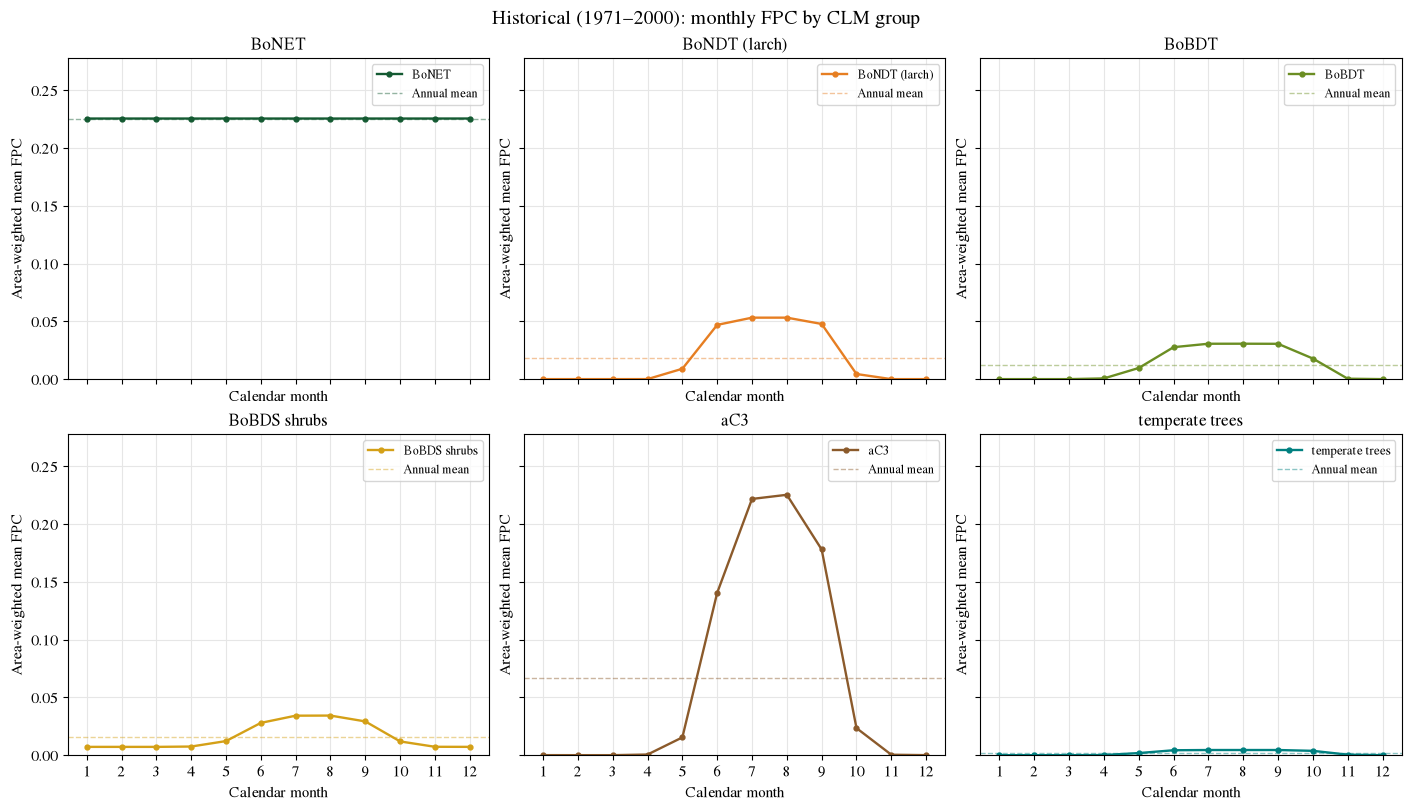

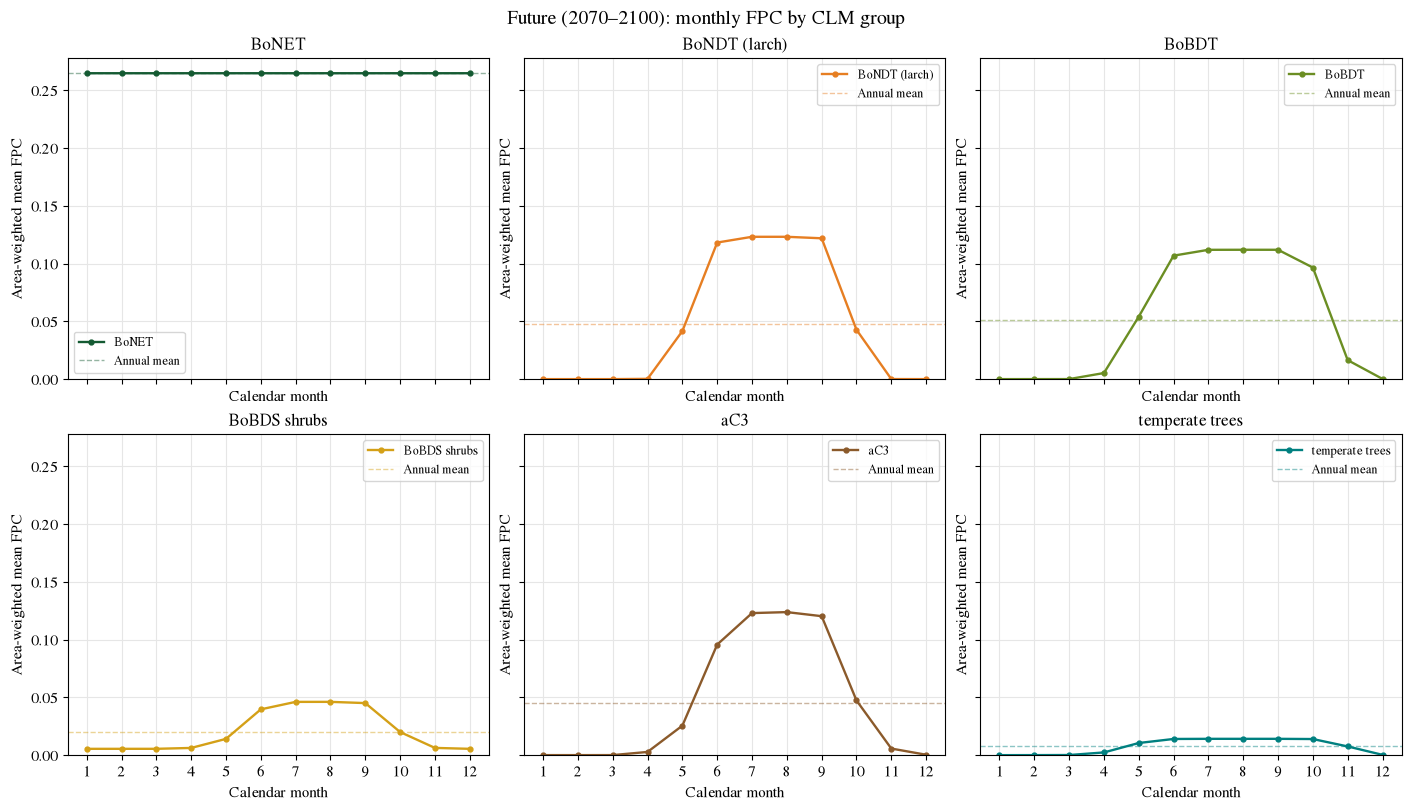

In [5]:
def plot_seasonal_cycles(period):
    seasonal = weighted_mean(data[period]["fpc"])
    ymax = max(1.05 * max(float(weighted_mean(data[p]["fpc"]).max()) for p in data), 1e-6)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes = axes.ravel()

    for ax, group in zip(axes, GROUPS):
        cycle = seasonal.sel(group=group)
        color = GROUP_COLORS[group]
        ax.plot(cycle.month, cycle, color=color, marker="o", markersize=3.5,
                linewidth=1.7, label=group)
        ax.axhline(float(cycle.mean("month")), color=color, linestyle="--",
                   linewidth=1.0, alpha=0.45, label="Annual mean")
        ax.set(title=group, xticks=range(1, 13), xlabel="Calendar month",
               ylabel="Area-weighted mean FPC", ylim=(0, ymax))
        ax.grid(color="0.9")
        ax.set_axisbelow(True)
        ax.legend(fontsize=9)

    for ax in axes[len(GROUPS):]:
        ax.set_axis_off()

    fig.suptitle(f"{period}: monthly FPC by CLM group", fontsize=14)
    save_figure(fig, f"{period}_grouped_fpc_seasonal_cycles")
    plt.show()


for period in data:
    plot_seasonal_cycles(period)

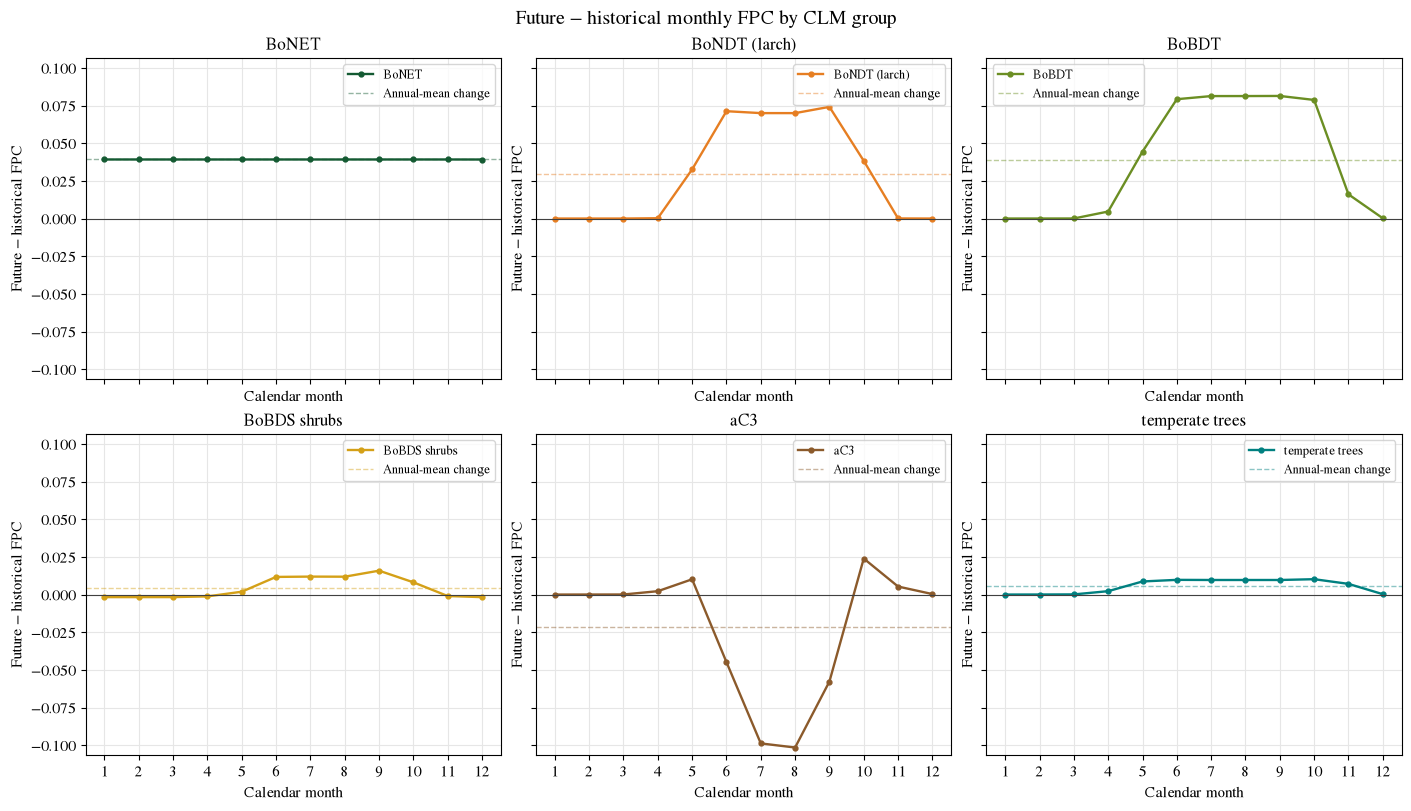

In [6]:
def plot_seasonal_cycle_changes():
    historical = weighted_mean(data[historical_name]["fpc"])
    future = weighted_mean(data[future_name]["fpc"])
    change = future - historical
    finite = np.abs(change.values[np.isfinite(change.values)])
    ymax = max(1.05 * float(finite.max()), 1e-6) if finite.size else 1e-6

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes = axes.ravel()

    for ax, group in zip(axes, GROUPS):
        cycle_change = change.sel(group=group)
        color = GROUP_COLORS[group]
        ax.plot(cycle_change.month, cycle_change, color=color, marker="o",
                markersize=3.5, linewidth=1.7, label=group)
        ax.axhline(float(cycle_change.mean("month")), color=color, linestyle="--",
                   linewidth=1.0, alpha=0.45, label="Annual-mean change")
        ax.axhline(0, color="0.25", linewidth=0.8)
        ax.set(title=group, xticks=range(1, 13), xlabel="Calendar month",
               ylabel="Future − historical FPC", ylim=(-ymax, ymax))
        ax.grid(color="0.9")
        ax.set_axisbelow(True)
        ax.legend(fontsize=9)

    for ax in axes[len(GROUPS):]:
        ax.set_axis_off()

    fig.suptitle("Future − historical monthly FPC by CLM group", fontsize=14)
    save_figure(fig, "future_minus_historical_grouped_fpc_seasonal_cycles")
    plt.show()


plot_seasonal_cycle_changes()

## 5 · Annual, JJA, and peak FPC comparison

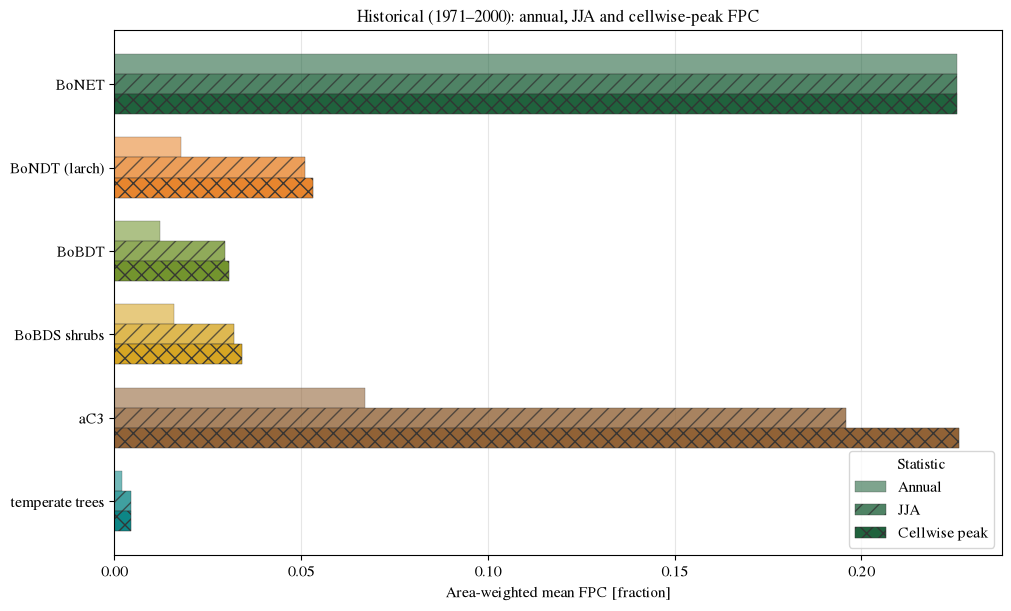

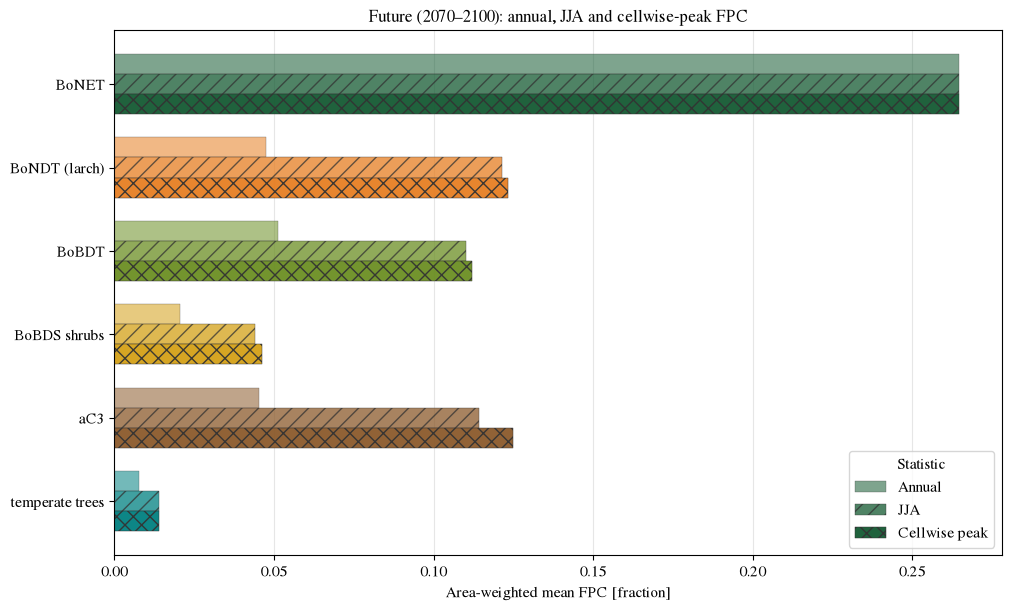

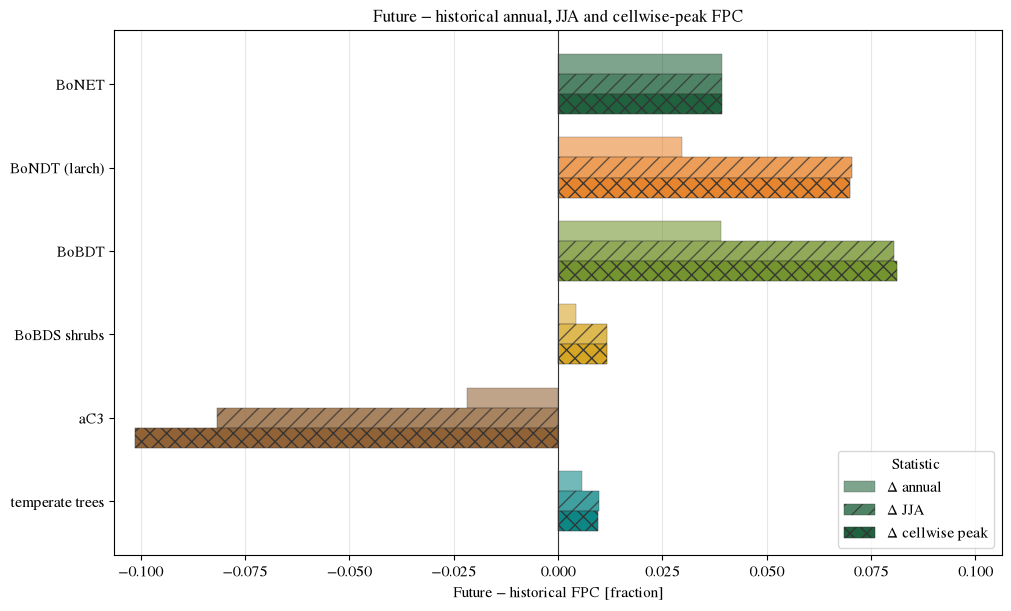

In [7]:
def plot_period_metric_comparison(period):
    table = summary.loc[summary.period == period].set_index("CLM group").loc[list(GROUPS)]
    metrics = ["annual mean FPC", "JJA mean FPC", "peak FPC"]
    labels = ["Annual", "JJA", "Cellwise peak"]
    hatches = ["", "//", "xx"]
    y = np.arange(len(table))
    height = 0.24
    colors = [GROUP_COLORS[group] for group in table.index]

    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    for index, (metric, label, hatch) in enumerate(zip(metrics, labels, hatches)):
        ax.barh(y + (index - 1) * height, table[metric], height=height, color=colors,
                alpha=0.55 + 0.2 * index, edgecolor="0.2", linewidth=0.35,
                hatch=hatch, label=label)
    ax.set(yticks=y, yticklabels=table.index, xlabel="Area-weighted mean FPC [fraction]",
           title=f"{period}: annual, JJA and cellwise-peak FPC")
    ax.invert_yaxis()
    ax.grid(axis="x", color="0.9")
    ax.set_axisbelow(True)
    ax.legend(title="Statistic", loc="lower right")
    save_figure(fig, f"{period}_grouped_annual_jja_peak_fpc")
    plt.show()


for period in data:
    plot_period_metric_comparison(period)


def plot_period_metric_changes():
    metrics = ["annual mean FPC", "JJA mean FPC", "peak FPC"]
    labels = ["Δ annual", "Δ JJA", "Δ cellwise peak"]
    hatches = ["", "//", "xx"]
    historical = summary.loc[summary.period == historical_name].set_index("CLM group").loc[list(GROUPS)]
    future = summary.loc[summary.period == future_name].set_index("CLM group").loc[list(GROUPS)]
    change = future[metrics] - historical[metrics]
    colors = [GROUP_COLORS[group] for group in change.index]
    y = np.arange(len(change))
    height = 0.24
    xmax = max(1.05 * float(np.abs(change).max().max()), 1e-6)

    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    for index, (metric, label, hatch) in enumerate(zip(metrics, labels, hatches)):
        ax.barh(y + (index - 1) * height, change[metric], height=height,
                color=colors, alpha=0.55 + 0.2 * index, edgecolor="0.2",
                linewidth=0.35, hatch=hatch, label=label)
    ax.axvline(0, color="0.2", linewidth=0.8)
    ax.set(yticks=y, yticklabels=change.index, xlabel="Future − historical FPC [fraction]",
           title="Future − historical annual, JJA and cellwise-peak FPC",
           xlim=(-xmax, xmax))
    ax.invert_yaxis()
    ax.grid(axis="x", color="0.9")
    ax.set_axisbelow(True)
    ax.legend(title="Statistic", loc="lower right")
    save_figure(fig, "future_minus_historical_grouped_annual_jja_peak_fpc")
    plt.show()


plot_period_metric_changes()

## 6 · Arctic FPC maps for every CLM group and period

Common normalized-correction scale: 0–1693.2%


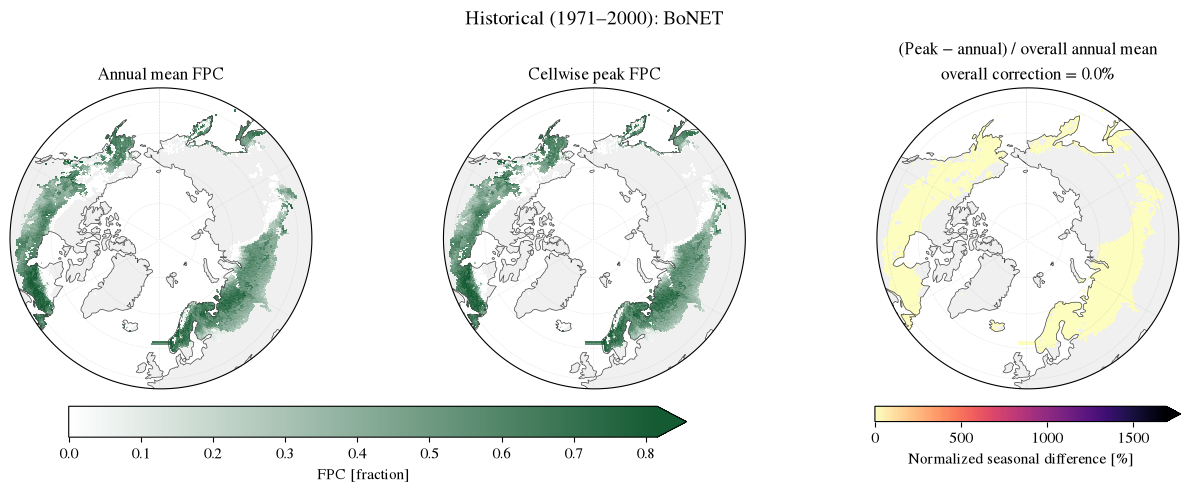

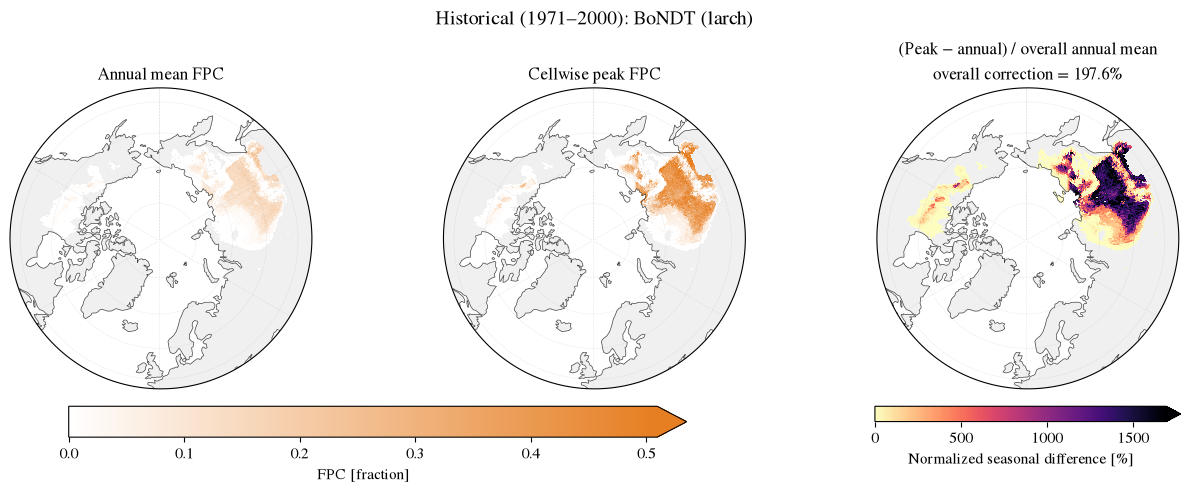

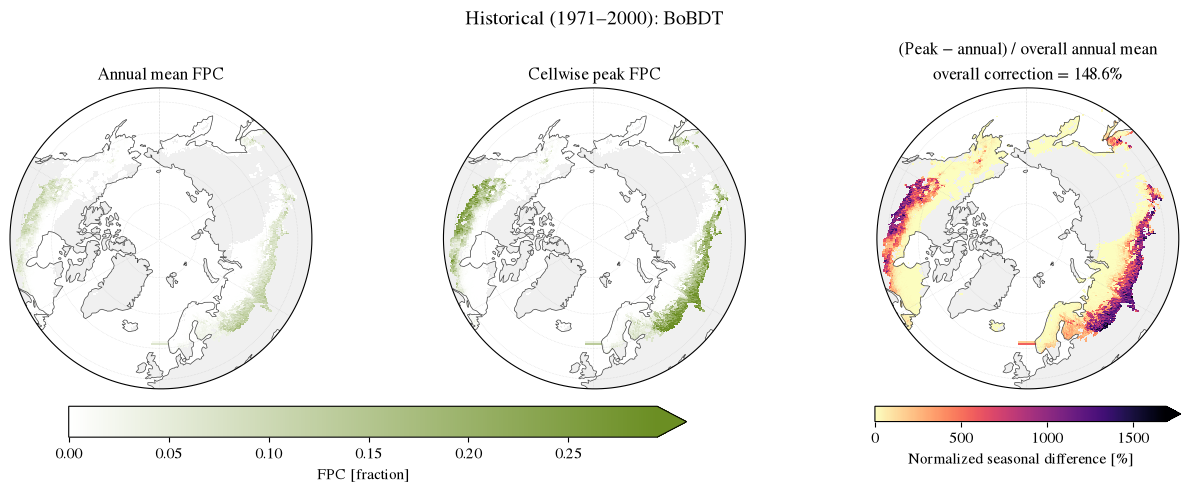

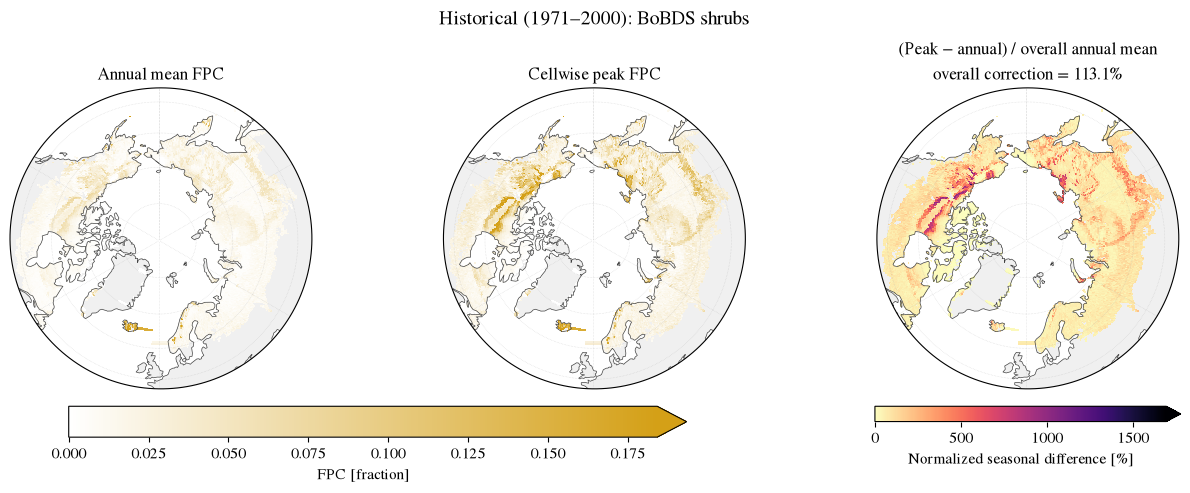

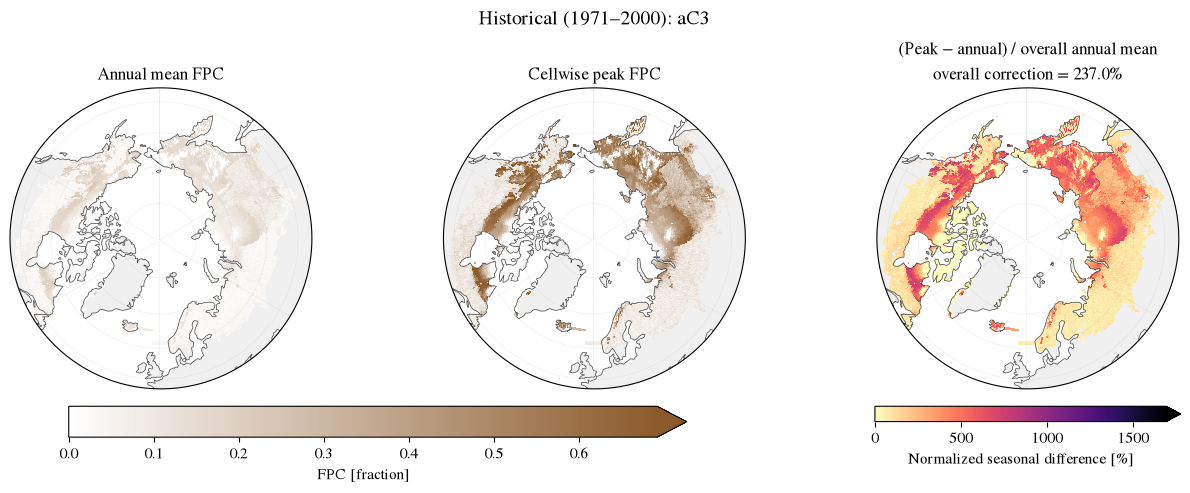

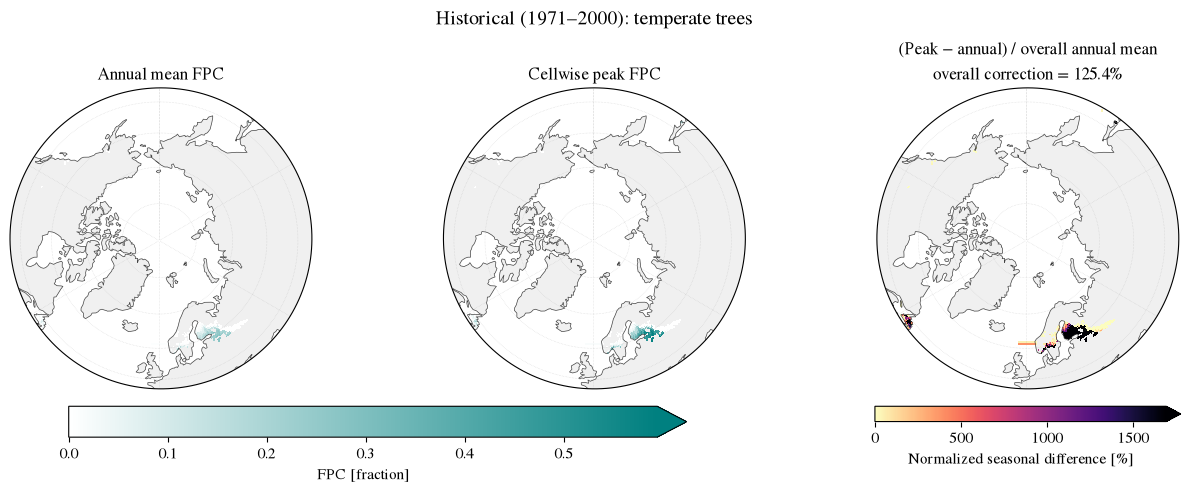

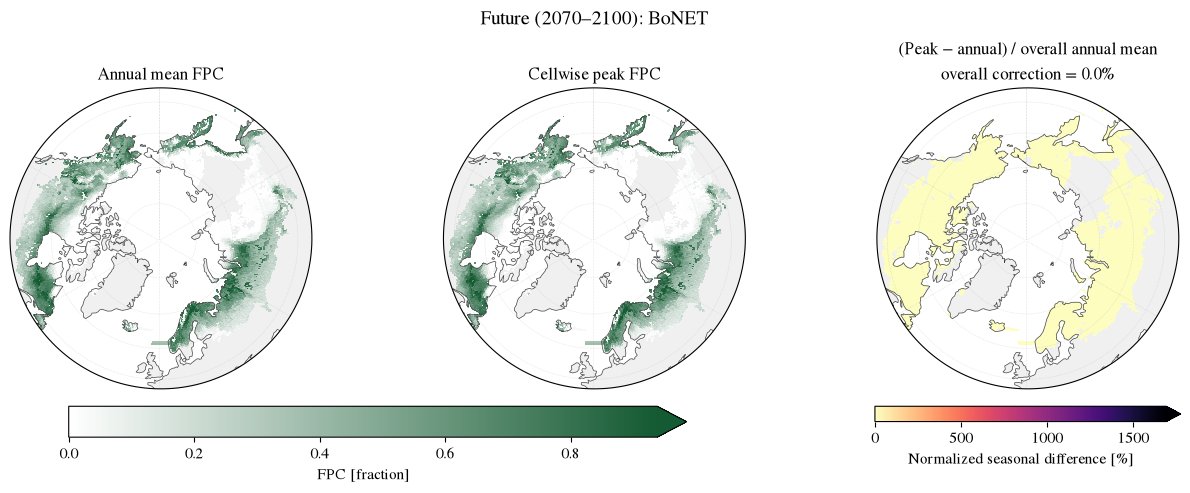

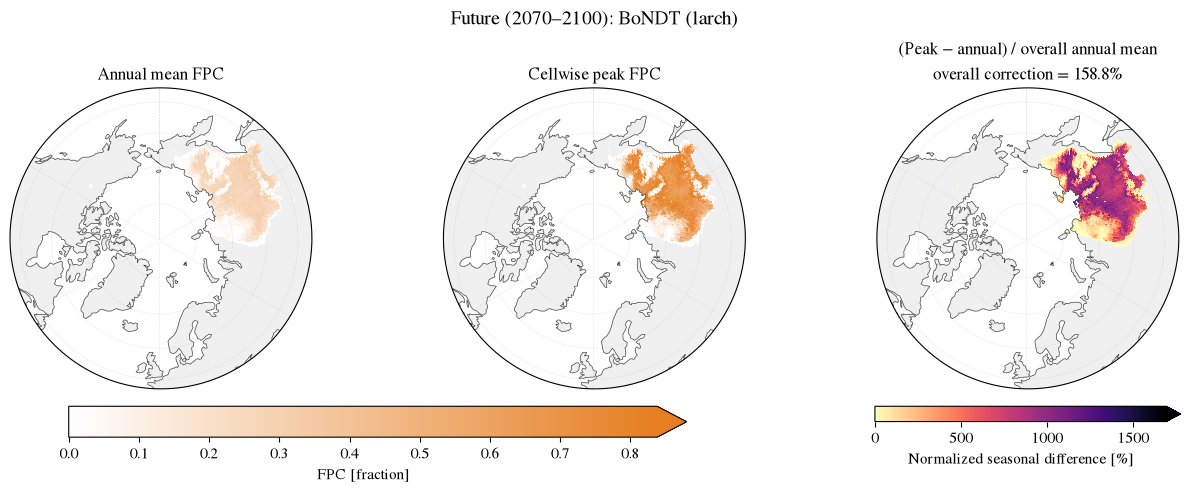

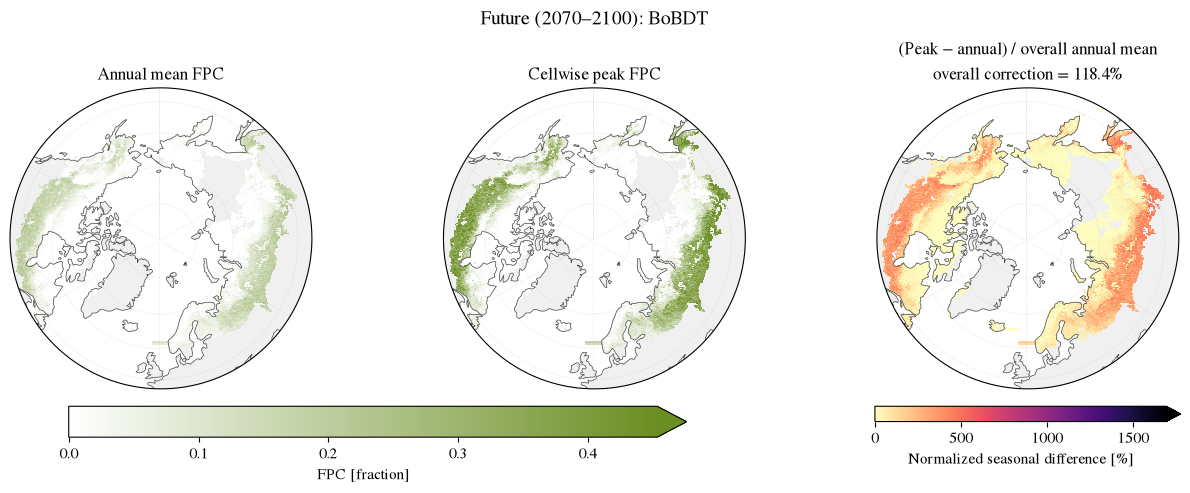

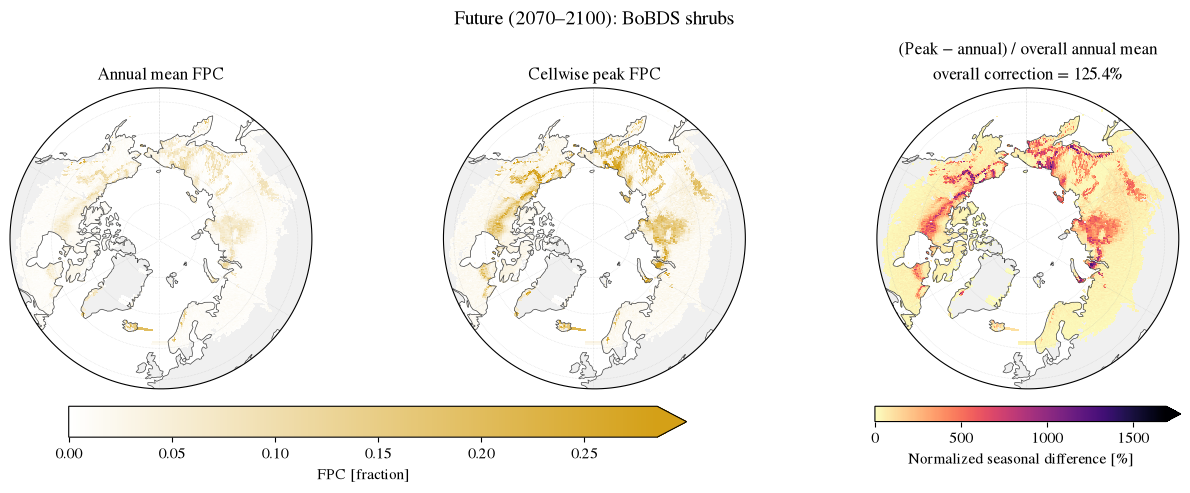

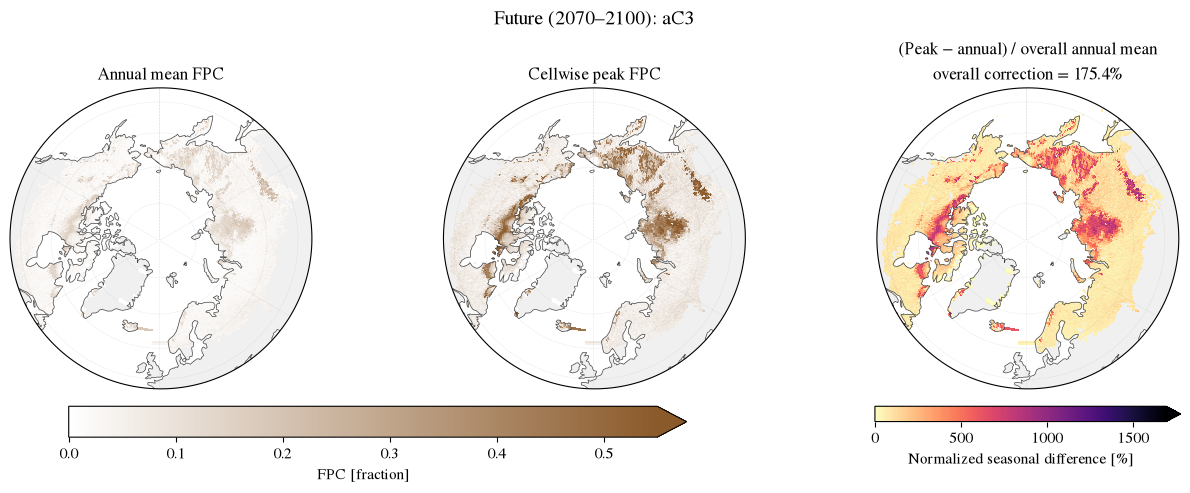

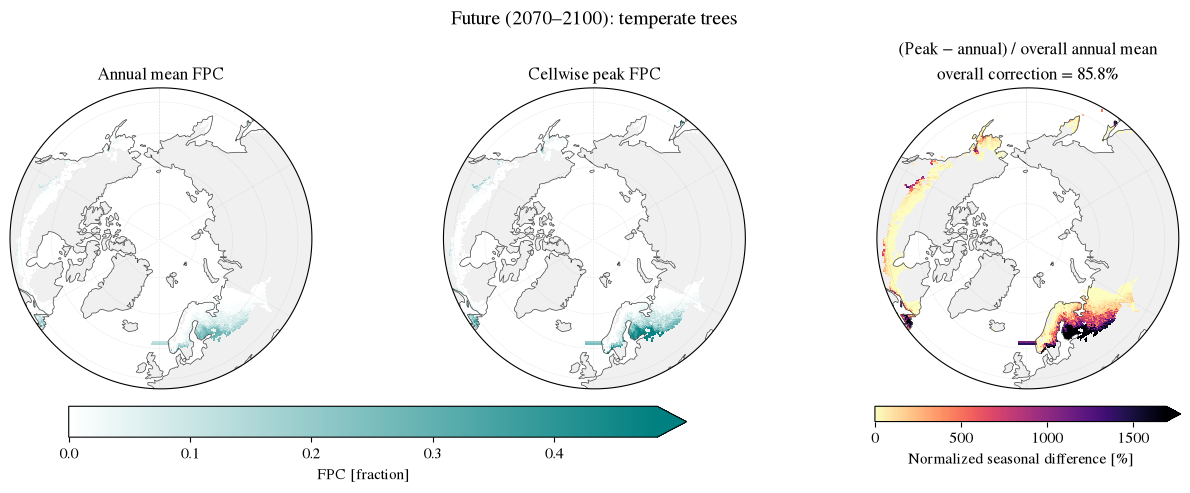

In [8]:
def robust_upper(fields, percentile=SCALE_PERCENTILE):
    arrays = [field.values[np.isfinite(field.values)] for field in fields
              if np.isfinite(field.values).any()]
    return max(float(np.percentile(np.concatenate(arrays), percentile)), 1e-6) if arrays else 1e-6


def configure_arctic_axis(ax):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.coastlines(linewidth=0.5, color="0.25")
    ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.4, color="0.65",
                 alpha=0.5, linestyle=":")
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(circle), transform=ax.transAxes)


map_cache = {}
all_normalized_values = []
for period in data:
    derived = data[period]["derived"]
    map_cache[period] = {}
    for group in GROUPS_TO_MAP:
        annual_raw = derived.annual_mean_fpc.sel(group=group)
        peak_raw = derived.peak_fpc.sel(group=group)
        active = np.isfinite(annual_raw) & np.isfinite(peak_raw) & (peak_raw > PRESENCE_THRESHOLD)
        overall_annual = float(weighted_mean(annual_raw))
        normalized = (
            (100 * (peak_raw - annual_raw) / overall_annual).where(active)
            if overall_annual > 0 else xr.full_like(annual_raw, np.nan)
        )
        overall_peak = float(weighted_mean(peak_raw))
        map_cache[period][group] = {
            "annual": annual_raw.where(active),
            "peak": peak_raw.where(active),
            "normalized": normalized,
            "overall correction": (
                100 * (overall_peak - overall_annual) / overall_annual
                if overall_annual > 0 else np.nan
            ),
        }
        values = normalized.values
        all_normalized_values.append(values[np.isfinite(values)])

nonempty_normalized = [values for values in all_normalized_values if values.size]
NORMALIZED_VMAX = (
    max(float(np.percentile(np.concatenate(nonempty_normalized), SCALE_PERCENTILE)), 1e-6)
    if nonempty_normalized else 1e-6
)
print(f"Common normalized-correction scale: 0–{NORMALIZED_VMAX:.1f}%")


def plot_group_maps(period, group):
    fields = map_cache[period][group]
    color = GROUP_COLORS[group]
    group_cmap = LinearSegmentedColormap.from_list(f"{slug(group)}_fpc", ["#FFFFFF", color])
    absolute_norm = Normalize(0, robust_upper([fields["annual"], fields["peak"]]))
    normalized_norm = Normalize(0, NORMALIZED_VMAX)
    projection = ccrs.Orthographic(central_longitude=0, central_latitude=90)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), subplot_kw={"projection": projection},
                             layout="constrained")
    plot_specs = [
        (fields["annual"], "Annual mean FPC", group_cmap, absolute_norm),
        (fields["peak"], "Cellwise peak FPC", group_cmap, absolute_norm),
        (fields["normalized"], "(Peak − annual) / overall annual mean\n"
         f"overall correction = {fields['overall correction']:.1f}%", "magma_r", normalized_norm),
    ]
    images = []
    for ax, (field, title, cmap, norm) in zip(axes, plot_specs):
        configure_arctic_axis(ax)
        image = ax.pcolormesh(field.lon, field.lat, field, transform=ccrs.PlateCarree(),
                              shading="auto", cmap=cmap, norm=norm, rasterized=True)
        ax.set_title(title)
        images.append(image)

    absolute_bar = fig.colorbar(images[0], ax=axes[:2], orientation="horizontal",
                                shrink=0.72, pad=0.05, extend="max")
    absolute_bar.set_label("FPC [fraction]")
    normalized_bar = fig.colorbar(images[2], ax=axes[2], orientation="horizontal",
                                  shrink=0.72, pad=0.05, extend="max")
    normalized_bar.set_label("Normalized seasonal difference [%]")
    fig.suptitle(f"{period}: {group}", fontsize=14)
    save_figure(fig, f"{period}_{group}_fpc_maps")
    plt.show()


for period in data:
    for group in GROUPS_TO_MAP:
        plot_group_maps(period, group)

## 7 · Future minus historical FPC maps

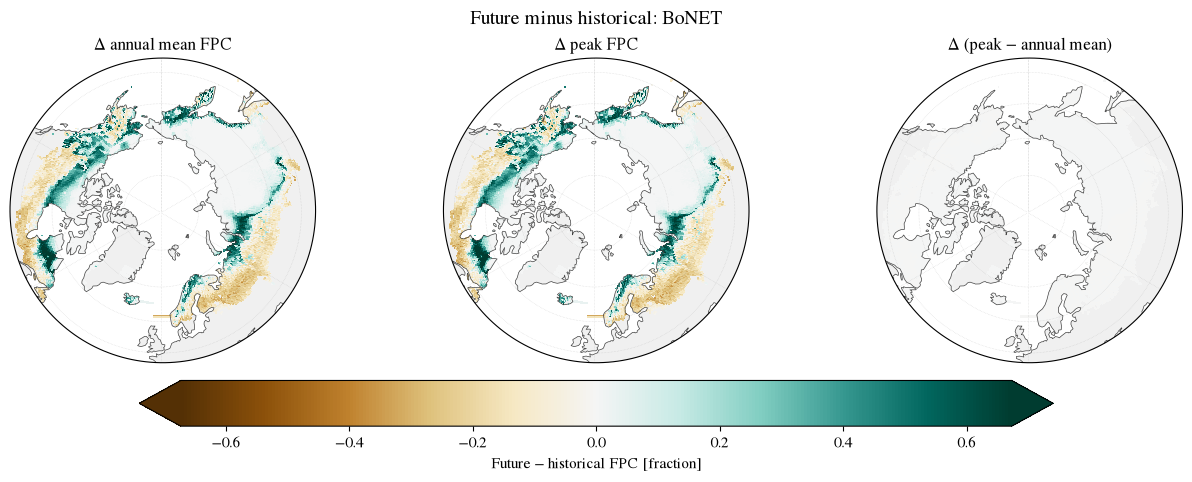

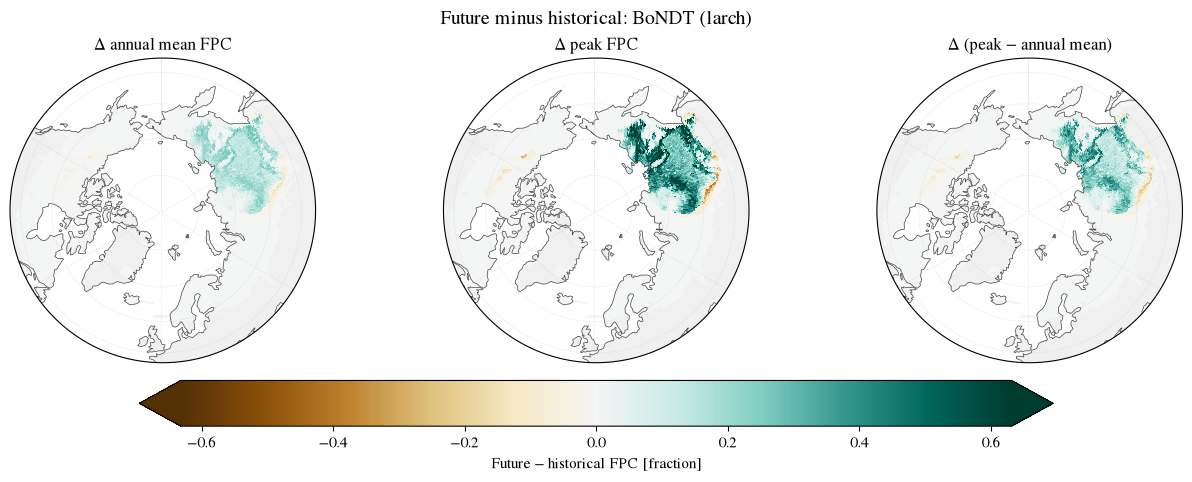

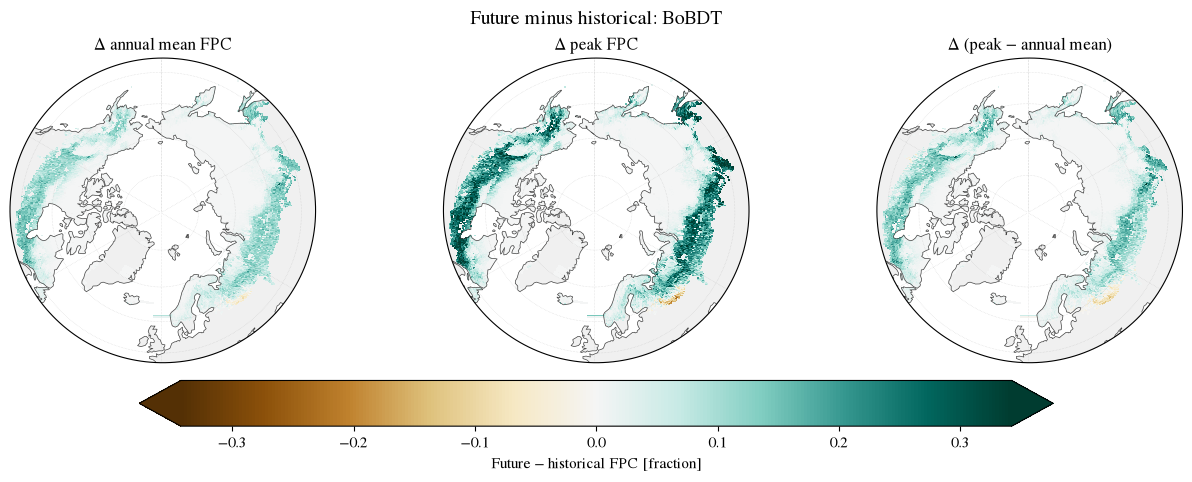

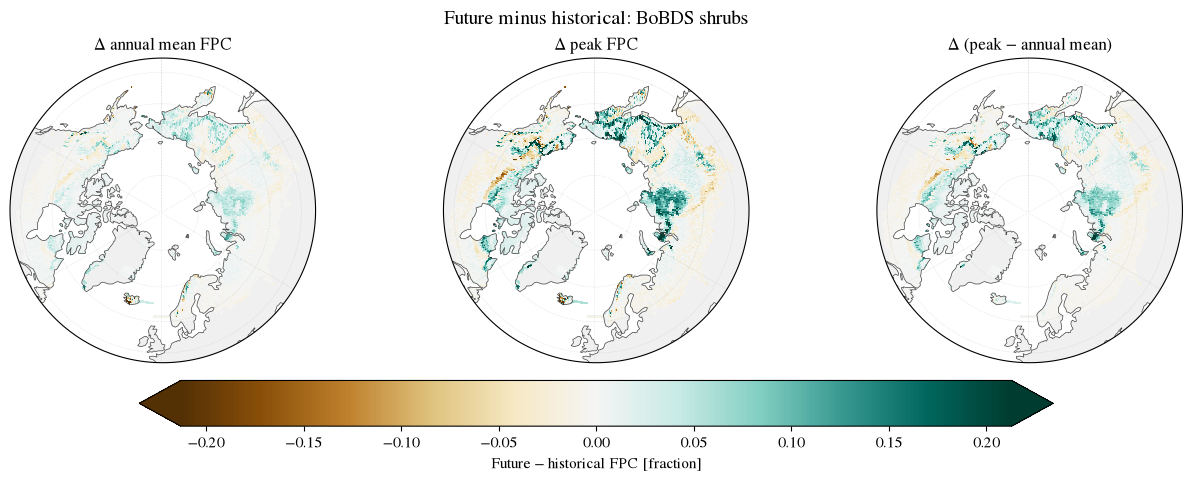

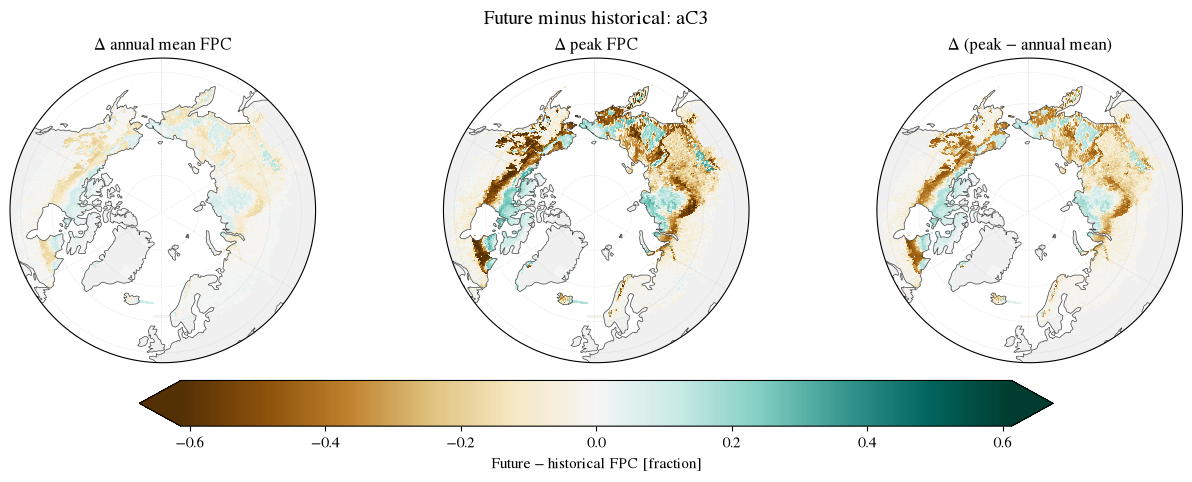

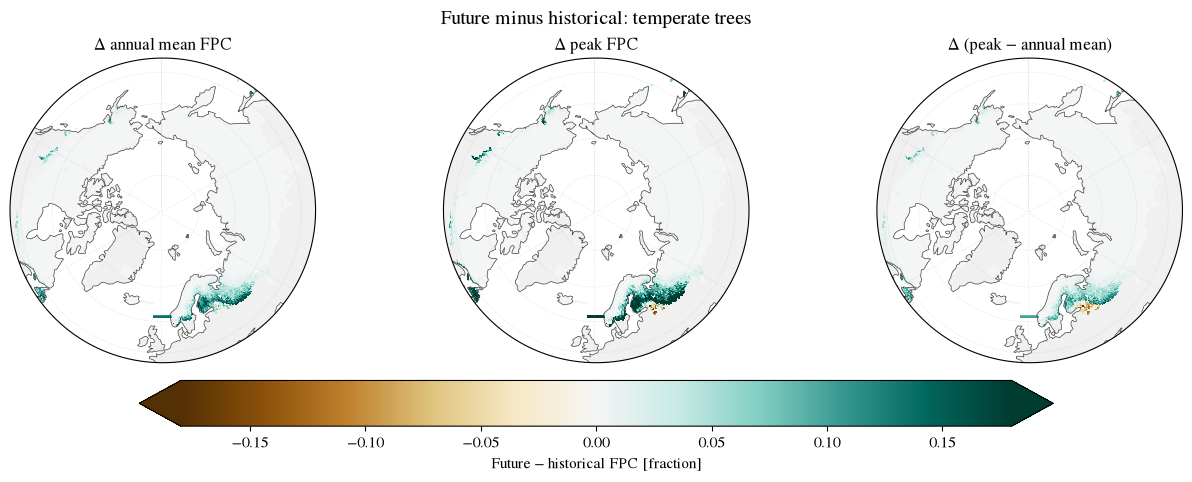

In [9]:
def plot_period_change_maps(group):
    historical = data[historical_name]["derived"].sel(group=group)
    future = data[future_name]["derived"].sel(group=group)
    historical_seasonal = historical.peak_fpc - historical.annual_mean_fpc
    future_seasonal = future.peak_fpc - future.annual_mean_fpc
    changes = [
        future.annual_mean_fpc - historical.annual_mean_fpc,
        future.peak_fpc - historical.peak_fpc,
        future_seasonal - historical_seasonal,
    ]
    titles = ["Δ annual mean FPC", "Δ peak FPC", "Δ (peak − annual mean)"]
    arrays = [field.values[np.isfinite(field.values)] for field in changes
              if np.isfinite(field.values).any()]
    values = np.concatenate(arrays) if arrays else np.array([0.0])
    vmax = max(float(np.percentile(np.abs(values), SCALE_PERCENTILE)), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    projection = ccrs.Orthographic(central_longitude=0, central_latitude=90)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.7), subplot_kw={"projection": projection},
                             layout="constrained")

    for ax, field, title in zip(axes, changes, titles):
        configure_arctic_axis(ax)
        image = ax.pcolormesh(field.lon, field.lat, field, transform=ccrs.PlateCarree(),
                              shading="auto", cmap="BrBG", norm=norm, rasterized=True)
        ax.set_title(title)
    colorbar = fig.colorbar(image, ax=axes, orientation="horizontal", shrink=0.72,
                            pad=0.05, extend="both")
    colorbar.set_label("Future − historical FPC [fraction]")
    fig.suptitle(f"Future minus historical: {group}", fontsize=14)
    save_figure(fig, f"future_minus_historical_{group}_fpc_maps")
    plt.show()


for group in GROUPS_TO_MAP:
    plot_period_change_maps(group)

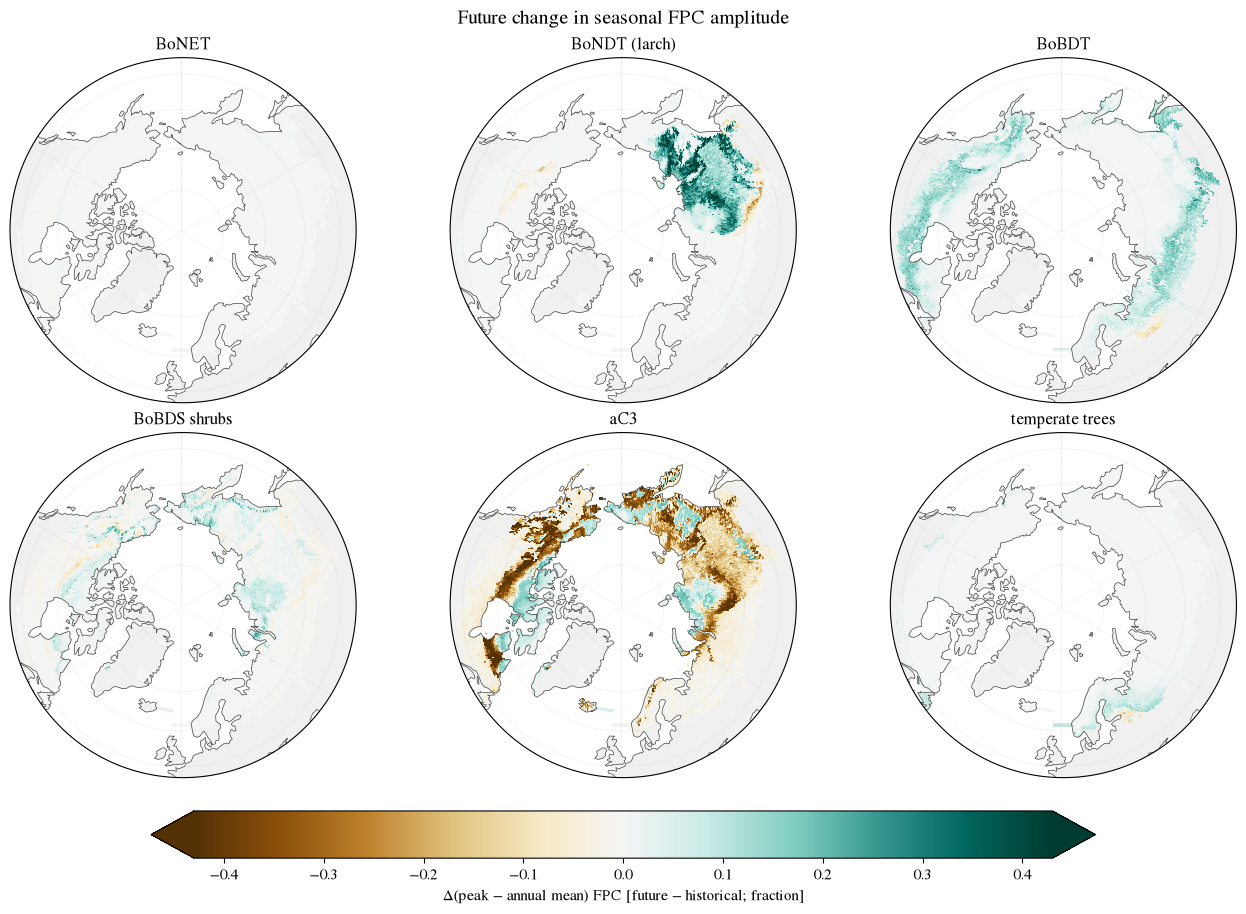

'\ndef plot_relative_seasonal_change_maps(groups=GROUPS_TO_MAP, min_denominator=1e-4):\n    relative_changes = {}\n\n    for group in groups:\n        historical = data[historical_name]["derived"].sel(group=group)\n        future = data[future_name]["derived"].sel(group=group)\n\n        historical_seasonal = historical.peak_fpc - historical.annual_mean_fpc\n        future_seasonal = future.peak_fpc - future.annual_mean_fpc\n\n        mean_seasonal = 0.5 * (future_seasonal + historical_seasonal)\n        relative_change = 100 * (future_seasonal - historical_seasonal) / mean_seasonal\n\n        # Relative changes are not meaningful where both seasonal contrasts\n        # are effectively zero.\n        relative_changes[group] = relative_change.where(\n            np.abs(mean_seasonal) >= min_denominator\n        )\n\n    arrays = [\n        field.values[np.isfinite(field.values)]\n        for field in relative_changes.values()\n        if np.isfinite(field.values).any()\n    ]\n    valu

In [15]:
def plot_seasonal_amplitude_change_maps(groups=GROUPS_TO_MAP):
    """Plot absolute changes in peak-minus-annual-mean FPC."""
    changes = {}

    for group in groups:
        historical = data[historical_name]["derived"].sel(group=group)
        future = data[future_name]["derived"].sel(group=group)

        historical_seasonal = (
            historical.peak_fpc - historical.annual_mean_fpc
        )
        future_seasonal = (
            future.peak_fpc - future.annual_mean_fpc
        )

        changes[group] = future_seasonal - historical_seasonal

    arrays = [
        field.values[np.isfinite(field.values)]
        for field in changes.values()
        if np.isfinite(field.values).any()
    ]
    values = np.concatenate(arrays) if arrays else np.array([0.0])

    vmax = max(
        float(np.percentile(np.abs(values), SCALE_PERCENTILE)),
        1e-6,
    )
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    projection = ccrs.Orthographic(
        central_longitude=0,
        central_latitude=90,
    )
    ncols = min(3, len(groups))
    nrows = int(np.ceil(len(groups) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 4.5 * nrows),
        subplot_kw={"projection": projection},
        layout="constrained",
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, group in zip(axes, groups):
        field = changes[group]

        configure_arctic_axis(ax)
        image = ax.pcolormesh(
            field.lon,
            field.lat,
            field,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap="BrBG",
            norm=norm,
            rasterized=True,
        )
        ax.set_title(group)

    for ax in axes[len(groups):]:
        ax.remove()

    colorbar = fig.colorbar(
        image,
        ax=axes[:len(groups)].tolist(),
        orientation="horizontal",
        shrink=0.72,
        pad=0.04,
        extend="both",
    )
    colorbar.set_label(
        "Δ(peak − annual mean) FPC "
        "[future − historical; fraction]"
    )

    fig.suptitle(
        "Future change in seasonal FPC amplitude",
        fontsize=14,
    )

    save_figure(
        fig,
        "absolute_change_peak_minus_annual_fpc_all_groups",
    )
    plt.show()


plot_seasonal_amplitude_change_maps()
"""
def plot_relative_seasonal_change_maps(groups=GROUPS_TO_MAP, min_denominator=1e-4):
    relative_changes = {}

    for group in groups:
        historical = data[historical_name]["derived"].sel(group=group)
        future = data[future_name]["derived"].sel(group=group)

        historical_seasonal = historical.peak_fpc - historical.annual_mean_fpc
        future_seasonal = future.peak_fpc - future.annual_mean_fpc

        mean_seasonal = 0.5 * (future_seasonal + historical_seasonal)
        relative_change = 100 * (future_seasonal - historical_seasonal) / mean_seasonal

        # Relative changes are not meaningful where both seasonal contrasts
        # are effectively zero.
        relative_changes[group] = relative_change.where(
            np.abs(mean_seasonal) >= min_denominator
        )

    arrays = [
        field.values[np.isfinite(field.values)]
        for field in relative_changes.values()
        if np.isfinite(field.values).any()
    ]
    values = np.concatenate(arrays) if arrays else np.array([0.0])

    vmax = max(float(np.percentile(np.abs(values), SCALE_PERCENTILE)), 1e-6)
    vmax = min(vmax, 200)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    projection = ccrs.Orthographic(central_longitude=0, central_latitude=90)
    ncols = min(3, len(groups))
    nrows = int(np.ceil(len(groups) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 4.5 * nrows),
        subplot_kw={"projection": projection},
        layout="constrained",
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, group in zip(axes, groups):
        field = relative_changes[group]
        configure_arctic_axis(ax)
        image = ax.pcolormesh(
            field.lon,
            field.lat,
            field,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap="BrBG",
            norm=norm,
            rasterized=True,
        )
        ax.set_title(group)

    for ax in axes[len(groups):]:
        ax.remove()

    colorbar = fig.colorbar(
        image,
        ax=axes[:len(groups)].tolist(),
        orientation="horizontal",
        shrink=0.72,
        pad=0.04,
        extend="both",
    )
    colorbar.set_label(
        "Relative change in peak − annual mean FPC [% of period mean]"
    )

    fig.suptitle(
        "Future relative change in seasonal FPC contrast",
        fontsize=14,
    )
    save_figure(fig, "relative_change_peak_minus_annual_fpc_all_groups")
    plt.show()


plot_relative_seasonal_change_maps()"""

## 9 · Saved figures

In [10]:
saved_figures = sorted(FIGURE_DIR.glob("*.png"))
print(f"Saved {len(saved_figures)} PNG figures and matching PDFs to {FIGURE_DIR.resolve()}")
#for path in saved_figures:
    #print(" ", path.name)

Saved 24 PNG figures and matching PDFs to /cluster/home/adelez/BOREAL-FOREST-EXPANSION/preprocess/edit-surfdatafile/fpc-to-pft-processing/monthly-lpjguess-fpc-exploration-figures/CLM-PFTs


## Three definitions of peak FPC

The monthly data allow three different definitions of “peak”. They answer different questions and should not be treated as interchangeable.

### 1. Cellwise peak FPC

For every grid cell, the maximum FPC is selected independently across the 12 months:

$$
FPC_{\mathrm{peak},i}=\max_m(FPC_{i,m})
$$

Different cells may therefore contribute values from different months. For example:

- western Siberia might contribute its July maximum;
- eastern Siberia might contribute its August maximum;
- another cell might contribute its September maximum.

This produces a synthetic maximum-coverage field, not a snapshot of one calendar month.

This is useful as a proxy for maximum seasonal vegetation coverage, but it cannot directly produce a single-month input file.

### 2. Spatial-mean peak month

FPC is first averaged spatially for every month. The month with the largest area-weighted regional mean is then selected:

$$
m_{\mathrm{peak}}
=
\arg\max_m\left(\overline{FPC_m}\right)
$$

In this analysis, the spatially averaged seasonal cycles generally peak in August. August is therefore used as a common peak-season snapshot for both the historical and future periods.

It means: August is the month in which the CLM group has its highest domain-wide, area-weighted mean FPC.

### 3. Modal cellwise peak month

The peak month is first identified separately in every grid cell. The modal peak month is the month occurring over the largest area, using latitude-weighted grid cells:

$$
m_{\mathrm{modal}}
=
\operatorname{mode}_i
\left(\arg\max_m FPC_{i,m}\right)
$$

This answers:

In which month do the largest number—or greatest weighted area—of grid cells reach their own maximum?

This describes the most common local timing of peak FPC. It does not account for the magnitude of FPC very strongly. Many low-FPC cells peaking in July could make July the mode, while fewer high-FPC cells make the regional average highest in August.

### 👉 Choice used for the exported files

I'll average July and August as "max FPC map".
